In [15]:
import tensorflow as tf
from tensorflow.keras.layers import Dense
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from utils import show_first_five

## Generating Data

In [16]:
X, y = make_circles(
    n_samples=500,
    noise=0.08,
    factor=0.4,
    random_state=42
)


## Seeing Data


In [17]:
print(X.shape)
print(y.shape)

print(X[:5])
print(y[:5])

(500, 2)
(500,)
[[-0.37534845  0.19833199]
 [-0.1061581   0.99849163]
 [-0.35445221  0.02190658]
 [-0.63517376 -0.64203511]
 [-0.80399496  0.64833975]]
[1 0 1 0 0]


## Plotting Data

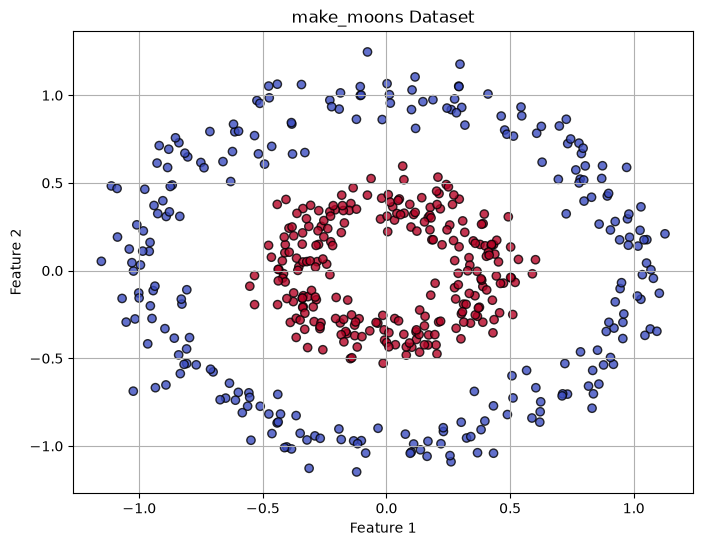

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="coolwarm", # Color Map list Below 👇
    edgecolors="k",
    alpha = 0.8
)
# ['PiYG', 'PRGn', 'BrBG', 'PuOr', 'RdGy', 'RdBu', 'RdYlBu', 'RdYlGn', \
    # 'Spectral', 'coolwarm', 'bwr', 'seismic', 'berlin', 'managua', 'vanimo']


plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("make_moons Dataset")
plt.grid(True)

plt.show()

## Train Test Splitting

In [19]:
x_train, _x, y_train, _y = train_test_split(X, y, test_size=0.3,random_state=True)
x_cv, x_test, y_cv, y_test = train_test_split(_x, _y, test_size=0.5,random_state=True)

print(x_train.shape, x_cv.shape, x_test.shape)

(350, 2) (75, 2) (75, 2)


In [20]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_cv_scaled = scaler.transform(x_cv)
x_cv_scaled = scaler.transform(x_cv)

x_cv_scaled[:5]

array([[ 1.47746426, -0.99066718],
       [ 0.73767223,  0.33737102],
       [-0.68891301,  0.19252541],
       [-1.29932929, -1.00642863],
       [-0.68605715,  0.66498638]])

## Built Model

In [ ]:
tf.random.set_seed(1234)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),
    Dense(25, activation='relu', name='L1'),
    Dense(15, activation='relu', name='L2'),
    Dense(1, activation='sigmoid', name='L3')
], name='Prototype_1')

model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(0.001),
    metrics=['accuracy']
)

In [24]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 25)             │            75 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481 (1.88 KB)

 Trainable params: 481 (1.88 KB)

 Non-trainable params: 0 (0.00 B)

## Training Model